In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)


In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

df = pd.read_csv(url, names=columns, sep=",\s*", engine="python")
df = df.replace("?", np.nan).dropna().reset_index(drop=True)

print("Dataset shape:", df.shape)


In [ ]:
df["income"] = df["income"].apply(lambda x: 1 if x == ">50K" else 0)


In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns
df = pd.get_dummies(df, columns=categorical_cols)


In [ ]:
X = df.drop("income", axis=1).values
y = df["income"].values

indices = np.arange(len(X))
np.random.shuffle(indices)

split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]



X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


In [ ]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8

X_train = (X_train - mean) / std
X_test  = (X_test - mean) / std


In [ ]:
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)


In [ ]:
class AdultNN(nn.Module):
    def __init__(self, input_size, hidden_size=512, num_classes=2):
        super(AdultNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


In [ ]:
model = AdultNN(input_size=X_train.shape[1])
print(model)
print("Total parameters:", sum(p.numel() for p in model.parameters()))


AdultNN(
  (fc1): Linear(in_features=104, out_features=512, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)
Total parameters: 54786


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

train_losses = []
train_accuracies = []
test_accuracies = []


In [ ]:
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        #forward pass : wTx+b
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        #backwards
        optimizer.zero_grad()
        loss.backward()     # compute gradient
        optimizer.step()    # update weights

        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    train_acc = 100 * correct / total
    train_losses.append(epoch_loss / len(train_loader))
    train_accuracies.append(train_acc)

    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        _, test_pred = torch.max(test_outputs.data, 1)
        test_acc = 100 * (test_pred == y_test_tensor).sum().item() / len(y_test_tensor)
        test_accuracies.append(test_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Loss: {epoch_loss:.4f} "
              f"Train Acc: {train_acc:.2f}% "
              f"Test Acc: {test_acc:.2f}%")


Epoch [10/100] Loss: 17.2510 Train Acc: 83.51% Test Acc: 83.67%
Epoch [20/100] Loss: 16.4064 Train Acc: 84.01% Test Acc: 84.09%
Epoch [30/100] Loss: 16.0224 Train Acc: 84.35% Test Acc: 84.37%
Epoch [40/100] Loss: 15.8274 Train Acc: 84.49% Test Acc: 84.55%
Epoch [50/100] Loss: 15.6357 Train Acc: 84.65% Test Acc: 84.67%
Epoch [60/100] Loss: 15.5326 Train Acc: 84.83% Test Acc: 84.75%
Epoch [70/100] Loss: 15.3442 Train Acc: 85.04% Test Acc: 84.78%
Epoch [80/100] Loss: 15.2412 Train Acc: 85.14% Test Acc: 84.87%
Epoch [90/100] Loss: 15.3065 Train Acc: 85.26% Test Acc: 85.03%
Epoch [100/100] Loss: 15.0987 Train Acc: 85.40% Test Acc: 85.25%


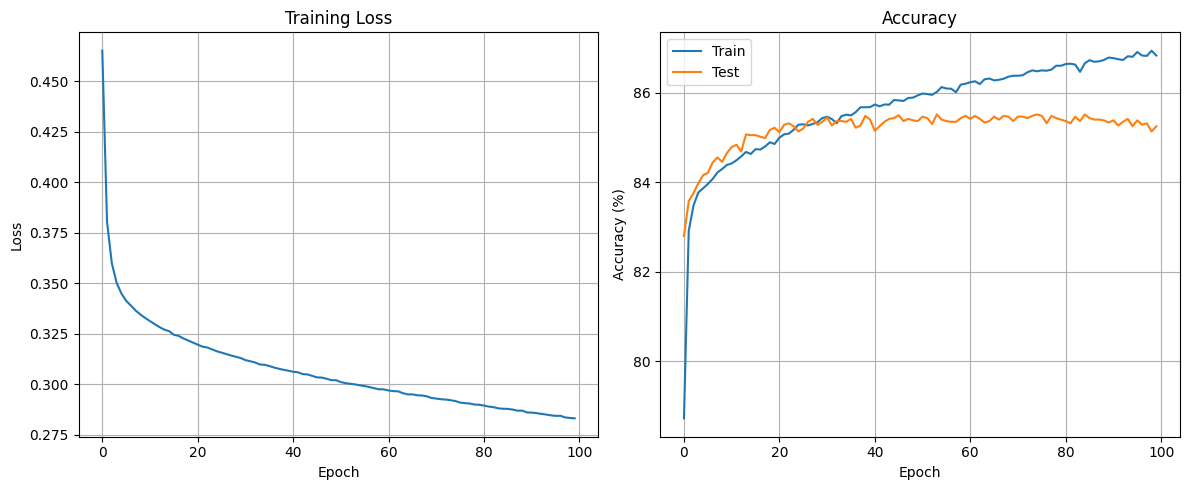

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train")
plt.plot(test_accuracies, label="Test")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
